# Toronto 311 Requests Project

## Import Libraries

In [151]:
# Data Manipulation
import numpy as np
import pandas as pd

# Data Visualization
import seaborn as sns
%matplotlib inline
import matplotlib.pyplot as plt
import geopandas as gpd

# Data modeling and evaluation

# Model Saving and Loading
import joblib

# Operating System
import os

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

## Data Loading

Critical information

- ward profile dosyasi incelendi bu dosya direkt ele alinacak dosya degil.
- burda istedigim bolum bize lazim. dosyanin icinde 'Income and shelter costs' bolumune gidip orde average ve median cost bolumunden median fiyat bilgileri biizm icin daha onemli.
- cunku outliera karsi daha iyi bir davaranis gostermis oluruz.
- "5 records (0.002% of the dataset) were excluded due to malformed rows in the source CSV, likely caused by inconsistent comma usage in the Section field for a small number of 'Transfer Station Odour Complaint' entries."

In [131]:
ward_list = []

for i in range(1, 26):
    ward_list.append(f'Ward {i}')

In [132]:
median_costs = [81000, 100000, 90000, 85000, 72000, 82000, 73000, 97000, 85000, 89000, 84000, 86000, 65000, 93000, 102000, 78500, 84000, 81000, 89000, 79000, 78000, 77000, 87000, 78000, 105000]

In [133]:
data_wards = pd.DataFrame({'Ward': ward_list, 'Median Cost': median_costs})

In [134]:
file_dir = 'C:\\Users\\Casper\\Desktop\\VS-CODE\\DataScienceProjects\\toronto_311_project\\data\\311_Service_Requests_2021.zip_unzipped\\SR2021.csv'

data_311_requests = pd.read_csv(
    file_dir,
    on_bad_lines='skip')

In [135]:
# Data Overview for 311 Service Requests
data_311_requests.head()

,Creation Date,Status,First 3 Chars of Postal Code,Intersection Street 1,Intersection Street 2,Ward,Service Request Type,Division,Section
0,2021-01-01 00:03:03.0000000,Closed,M2J,,,Don Valley North (17),Zoning ...,Municipal Licensing & Standards,District Enforcement
1,2021-01-01 00:08:02.0000000,Closed,M4B,,,Beaches-East York (19),Zoning ...,Municipal Licensing & Standards,District Enforcement
2,2021-01-01 00:09:00.0000000,Closed,M4R,,,Eglinton-Lawrence (08),Res / Organic Bin / Additional ...,Solid Waste Management Services,Collections
3,2021-01-01 00:10:24.0000000,Closed,M5E,,,Spadina-Fort York (10),Zoning ...,Municipal Licensing & Standards,District Enforcement
4,2021-01-01 00:17:49.0000000,Closed,M8Y,,,Etobicoke-Lakeshore (03),Zoning ...,Municipal Licensing & Standards,District Enforcement


In [136]:
# Data Overview for wards and their median costs
data_wards.head()

,Ward,Median Cost
0,Ward 1,81000
1,Ward 2,100000
2,Ward 3,90000
3,Ward 4,85000
4,Ward 5,72000


## EDA

### Wards Dataset

In [137]:
data_wards.shape

(25, 2)

In [138]:
data_wards.info()

<class 'pandas.DataFrame'>
RangeIndex: 25 entries, 0 to 24
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   Ward         25 non-null     str  
 1   Median Cost  25 non-null     int64
dtypes: int64(1), str(1)
memory usage: 532.0 bytes


In [139]:
data_wards.describe()

,Median Cost
count,25.000000
mean,84820.000000
std,9529.428105
min,65000.000000
25%,78500.000000
50%,84000.000000
75%,89000.000000
max,105000.000000


### 311 Requests Dataset

In [140]:
data_311_requests.info()

<class 'pandas.DataFrame'>
RangeIndex: 323880 entries, 0 to 323879
Data columns (total 9 columns):
 #   Column                                                           Non-Null Count   Dtype
---  ------                                                           --------------   -----
 0   Creation Date                                                    323880 non-null  str  
 1    Status                                                          323880 non-null  str  
 2    First 3 Chars of Postal Code                                    323880 non-null  str  
 3    Intersection Street 1                                           323880 non-null  str  
 4    Intersection Street 2                                           323880 non-null  str  
 5    Ward                                                            323880 non-null  str  
 6    Service Request Type                                            323880 non-null  str  
 7    Division                                                  

In [141]:
data_311_requests.describe()

,Creation Date,Status,First 3 Chars of Postal Code,Intersection Street 1,Intersection Street 2,Ward,Service Request Type,Division,Section
count,323880,323880,323880,323880,323880,323880,323880,323880,323880
unique,319884,6,101,4083,3848,26,476,8,20
top,2021-01-12 19:07:00.0000000,Closed,Intersection,,,Etobicoke-Lakeshore (03),Residential: Bin: Repair or Replace Lid ...,Solid Waste Management Services,Collections
freq,5,242934,34875,289005,289122,19787,14395,133950,133092


In [142]:
data_311_requests.columns

Index(['Creation Date              ', ' Status     ',
       ' First 3 Chars of Postal Code', ' Intersection Street 1           ',
       ' Intersection Street 2              ',
       ' Ward                         ',
       ' Service Request Type                                          ',
       ' Division                       ', ' Section'],
      dtype='str')

In [143]:
# Remove leading and trailing whitespace characters from column names
data_311_requests.columns = data_311_requests.columns.str.strip()

In [144]:
# Date Conversion: Convert the 'Creation Date' column to datetime format for easier analysis and manipulation of date-related data.
data_311_requests['Creation Date'] = pd.to_datetime(data_311_requests['Creation Date'])

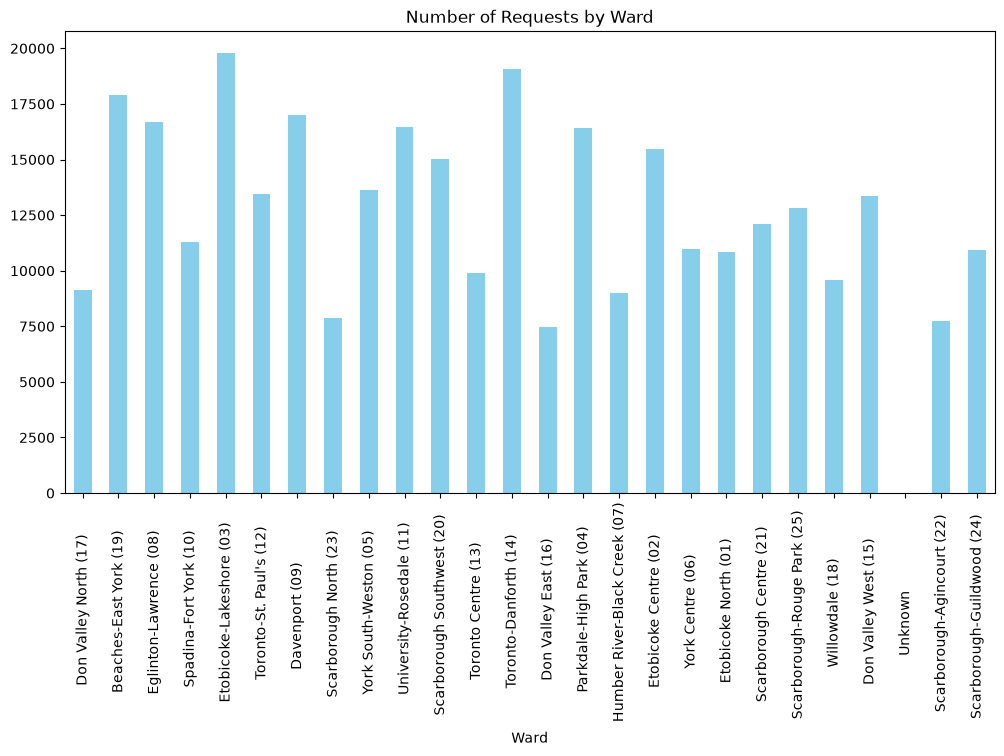

In [145]:
# Looking at the number of requests by ward
data_311_requests['Ward'].value_counts(sort=False).plot(kind='bar', figsize=(12, 6), title='Number of Requests by Ward', color='skyblue');

In [147]:
data_311_requests = data_311_requests[data_311_requests['Ward'].str.contains(r'\(', na=False)]

In [148]:
# splitting the 'Ward' column to extract the ward number and remove any leading/trailing whitespace and parentheses. This will help in cleaning the dataset and focusing on valid ward data.
data_311_requests['Ward'] = (
    data_311_requests['Ward']
    .str.split('(').str[1]      
    .str.strip()                
    .str.rstrip(')')             
    .astype(int)                 
    .apply(lambda x: f'Ward {x}')  
)

In [149]:
data_311_requests.head()

,Creation Date,Status,First 3 Chars of Postal Code,Intersection Street 1,Intersection Street 2,Ward,Service Request Type,Division,Section
0,2021-01-01 00:03:03,Closed,M2J,,,Ward 17,Zoning ...,Municipal Licensing & Standards,District Enforcement
1,2021-01-01 00:08:02,Closed,M4B,,,Ward 19,Zoning ...,Municipal Licensing & Standards,District Enforcement
2,2021-01-01 00:09:00,Closed,M4R,,,Ward 8,Res / Organic Bin / Additional ...,Solid Waste Management Services,Collections
3,2021-01-01 00:10:24,Closed,M5E,,,Ward 10,Zoning ...,Municipal Licensing & Standards,District Enforcement
4,2021-01-01 00:17:49,Closed,M8Y,,,Ward 3,Zoning ...,Municipal Licensing & Standards,District Enforcement


In [ ]:
# Dropping unnecessary columns 'Intersection Street 1' and 'Intersection Street 2' from the dataset to streamline the data for analysis.
data_311_requests = data_311_requests.drop(columns=['Intersection Street 1', 'Intersection Street 2'])

In [152]:
data = data_311_requests.merge(data_wards, on='Ward', how='left')

<Axes: >

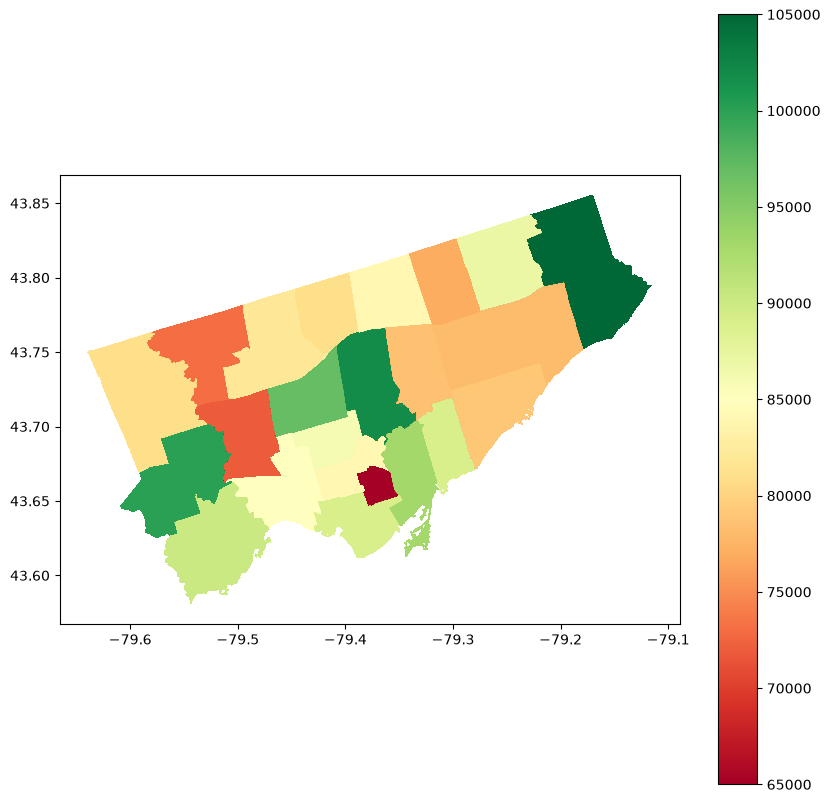

In [ ]:
wards_map = gpd.read_file('C:\\Users\\Casper\\Desktop\\VS-CODE\\DataScienceProjects\\toronto_311_project\\data\\City Wards Data - 4326.geojson')
wards_map['ward'] = wards_map['AREA_SHORT_CODE'].astype(int).apply(lambda x: f'Ward {x}')
# Merging the wards_map GeoDataFrame with the data DataFrame on the 'AREA_NAME' and 'Ward' columns to combine geographic information with the 311 service request data.
merged = wards_map.merge(data, left_on='ward', right_on='Ward')
merged.plot(column='Median Cost', cmap='RdYlGn', legend=True, figsize=(10,10))

## Train-Test Seperation Process 

## Data Modeling

## Model Evaluation  

## Model Saving